# 5.1 學習的流程
擬合(fit):從一堆意義不明的幾何數學漸漸構出數學定律
例子:萬有引力公式
焦點:一個軌道中的專注點
例子:克普勒第一&第二定理
一般來說
- 神經網路模型
- 針對特定功能訓練的模型
是不同的



# 5.2 學習就是在估算參數
模型計算參數改變所造成的誤差變化輛(梯度)是藉由使用連鎖法則對前後的神經曾函數進行權重變化

接下來會使用Pytorch進行訓練展示這過程

## 5.2.1 溫度計的單位
## 5.2.2 溫度計的資料
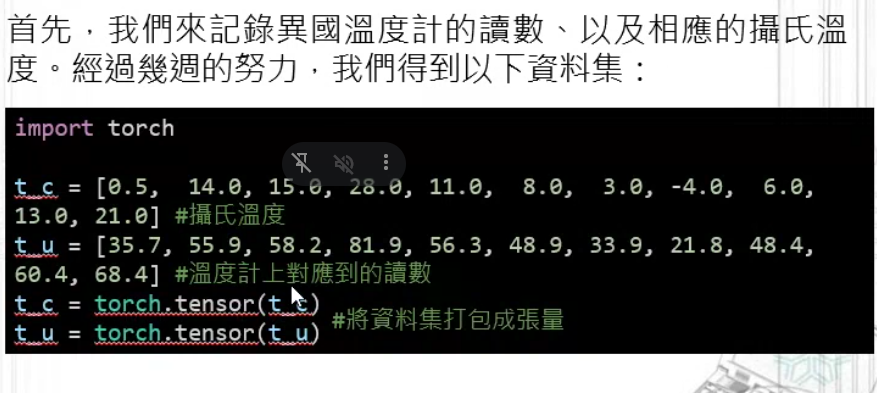
## 5.2.3 資料視覺化
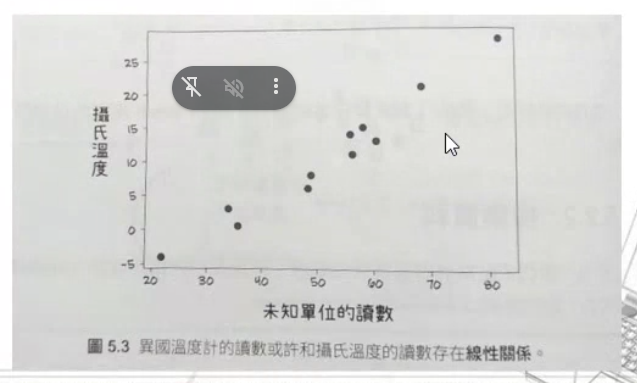
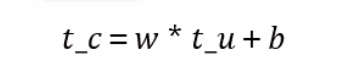


# 5.3 以降低損失為目標
### 損失函數(又稱:成本函數)

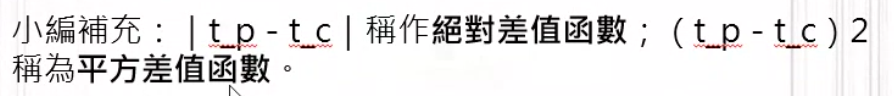

目標為降低損失及降低誤差,降低風險
相較於絕對差值函數,平方差值函數有著較為強力的**懲罰**作用
## 5.3.1 利用PyTorch解決問題
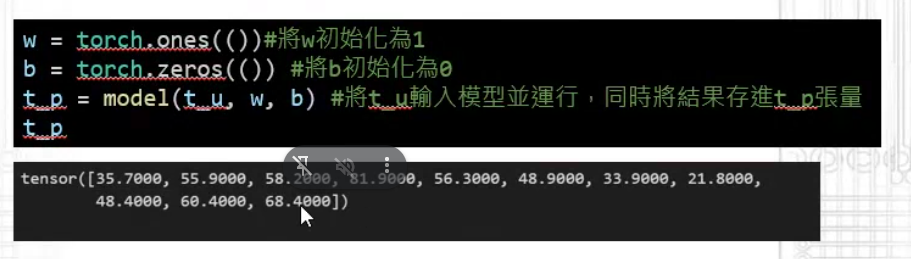


In [237]:
import torch
t_c =[0.5,14.0,15.0,28.0,11.0,8.0,3.0,-4.0,6.0,13.0,21.0]
t_u =[25.7,55.9,58.2,81.9,56.3,48.9,33.9,21.8,48.4,60.4,68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)


def model(t_c, w, b):
    return w * t_c + b
def loss_fn(t_p, t_u):
    squared_diffs = (t_p - t_u) ** 2
    return squared_diffs.mean()

In [238]:
w= torch.ones(())
b= torch.zeros(())
t_p = model(t_u, w, b)
t_p

tensor([25.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [239]:
loss = loss_fn(t_p, t_c)
loss

tensor(1708.9757)

# 5.4 梯度下降演算法
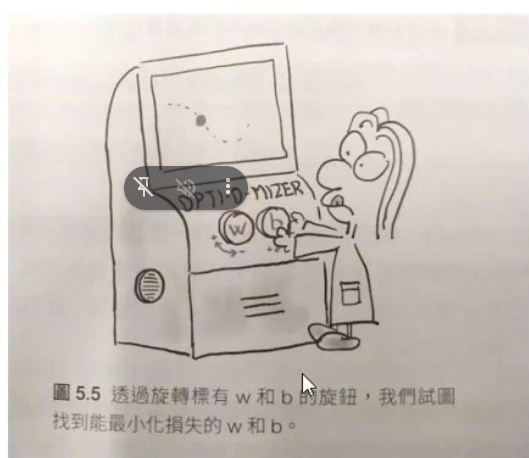

梯度下降的過程跟上述過程很相似
## 5.4.1 損失下降
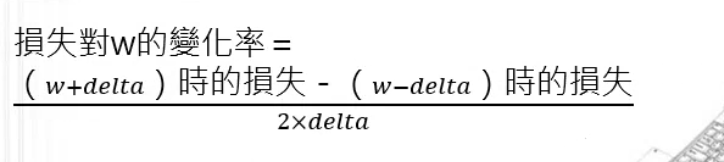
## 5.4.2 解析變化率
變化率相當於計算損失對模型參數的微分參數,這個過程就是所謂的**梯度**

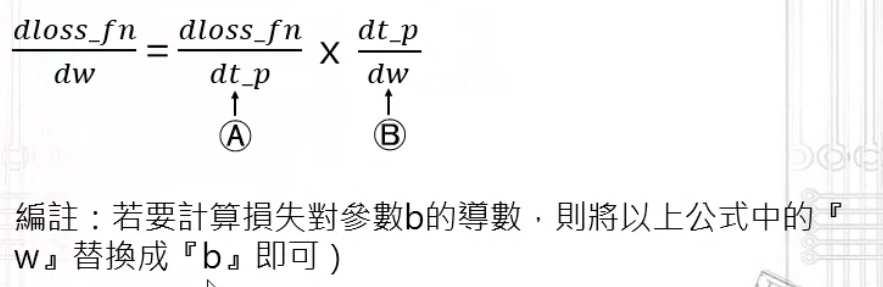

根據導數公式,我們要對模型做MSE

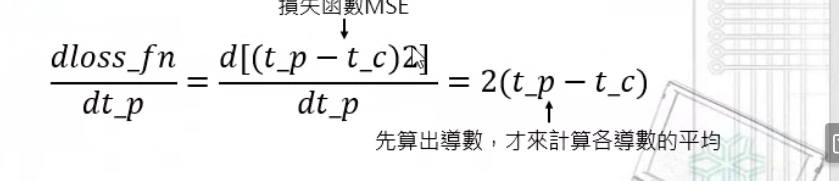

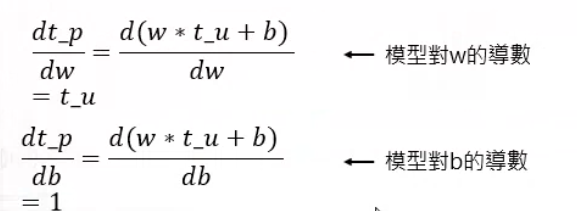


In [240]:
def dloss_fn(t_p, t_c):
    dl_dtp = 2.0 * (t_p - t_c) / t_c.size(0)
    return dl_dtp
def model(t_u, w, b):
    return w * t_u + b
def dmodel_dw(t_u, w, b):
    return t_u
def dmodel_db(t_u, w, b):
    return 1.0
def grad_fn(t_u, t_c, t_p, w, b):
    dl_dtp = dloss_fn(t_p, t_c)
    dtp_dw = dmodel_dw(t_u, w, b)
    dtp_db = dmodel_db(t_u, w, b)
    dl_dw = dl_dtp * dtp_dw
    dl_db = dl_dtp * dtp_db
    return torch.stack([dl_dw.sum(), dl_db.sum()])



## 5.4.3 透過迭代來擬合模型
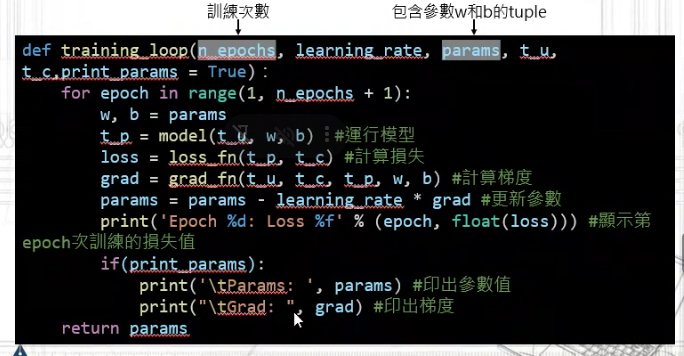
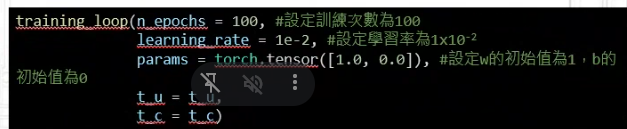
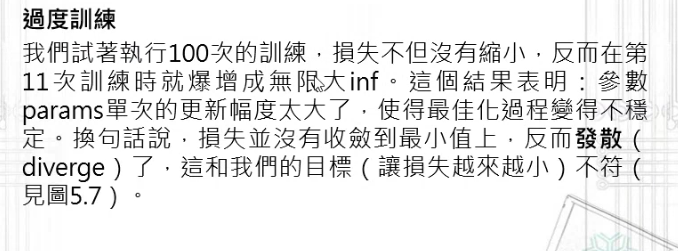


In [241]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c, print_params=True):
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model(t_u, w, b)
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)
        params = params - learning_rate * grad
        print("Epoch:", epoch, "Loss:", loss.item())
        if print_params:
            print("Params:", params)
            print("Grad:", grad)
    return params

In [242]:
training_loop(n_epochs=100, learning_rate=1e-2, \
                params= torch.tensor([1.0,0.0]), t_u=t_u, t_c=t_c)


Epoch: 1 Loss: 1708.9757080078125
Params: tensor([-43.0657,  -0.8078])
Grad: tensor([4406.5693,   80.7818])
Epoch: 2 Loss: 5413101.0
Params: tensor([2456.2637,   43.2514])
Grad: tensor([-249932.9375,   -4405.9199])
Epoch: 3 Loss: 17413216256.0
Params: tensor([-139299.5625,   -2457.4333])
Grad: tensor([14175583.0000,   250068.4844])
Epoch: 4 Loss: 56016255320064.0
Params: tensor([7900744.0000,  139373.5469])
Grad: tensor([-8.0400e+08, -1.4183e+07])
Epoch: 5 Loss: 1.801976206464123e+17
Params: tensor([-4.4811e+08, -7.9049e+06])
Grad: tensor([4.5601e+10, 8.0443e+08])
Epoch: 6 Loss: 5.796744224812732e+20
Params: tensor([2.5416e+10, 4.4835e+08])
Grad: tensor([-2.5864e+12, -4.5625e+10])
Epoch: 7 Loss: 1.864744032577587e+24
Params: tensor([-1.4415e+12, -2.5429e+10])
Grad: tensor([1.4669e+14, 2.5878e+12])
Epoch: 8 Loss: 5.998659811841462e+27
Params: tensor([8.1759e+13, 1.4423e+12])
Grad: tensor([-8.3201e+15, -1.4677e+14])
Epoch: 9 Loss: 1.9296977900309198e+31
Params: tensor([-4.6372e+15, -8.18

tensor([nan, nan])

In [243]:
training_loop(n_epochs=100, learning_rate=1e-4, \
                params= torch.tensor([1.0,0.0]), t_u=t_u, t_c=t_c)

Epoch: 1 Loss: 1708.9757080078125
Params: tensor([ 0.5593, -0.0081])
Grad: tensor([4406.5693,   80.7818])
Epoch: 2 Loss: 327.1012878417969
Params: tensor([ 0.3730, -0.0117])
Grad: tensor([1863.1742,   35.9148])
Epoch: 3 Loss: 80.04834747314453
Params: tensor([ 0.2942, -0.0134])
Grad: tensor([787.7647,  16.9439])
Epoch: 4 Loss: 35.87930679321289
Params: tensor([ 0.2609, -0.0143])
Grad: tensor([333.0550,   8.9225])
Epoch: 5 Loss: 27.98198890686035
Params: tensor([ 0.2469, -0.0148])
Grad: tensor([140.7929,   5.5308])
Epoch: 6 Loss: 26.569337844848633
Params: tensor([ 0.2409, -0.0152])
Grad: tensor([59.4996,  4.0967])
Epoch: 7 Loss: 26.316022872924805
Params: tensor([ 0.2384, -0.0156])
Grad: tensor([25.1269,  3.4903])
Epoch: 8 Loss: 26.269977569580078
Params: tensor([ 0.2373, -0.0159])
Grad: tensor([10.5933,  3.2338])
Epoch: 9 Loss: 26.2609806060791
Params: tensor([ 0.2369, -0.0162])
Grad: tensor([4.4481, 3.1254])
Epoch: 10 Loss: 26.25861167907715
Params: tensor([ 0.2367, -0.0165])
Grad: t

tensor([ 0.2371, -0.0439])

In [244]:
t_un = 0.1*t_u
training_loop(n_epochs=100, learning_rate=1e-2, \
                params= torch.tensor([1.0,0.0]), t_u=t_un, t_c=t_c)

Epoch: 1 Loss: 79.8970718383789
Params: tensor([1.7864, 0.1082])
Grad: tensor([-78.6395, -10.8218])
Epoch: 2 Loss: 35.60335922241211
Params: tensor([2.1080, 0.1342])
Grad: tensor([-32.1633,  -2.6013])
Epoch: 3 Loss: 28.26116943359375
Params: tensor([2.2414, 0.1270])
Grad: tensor([-13.3405,   0.7244])
Epoch: 4 Loss: 26.979896545410156
Params: tensor([2.2986, 0.1063])
Grad: tensor([-5.7168,  2.0677])
Epoch: 5 Loss: 26.693012237548828
Params: tensor([2.3249, 0.0802])
Grad: tensor([-2.6287,  2.6082])
Epoch: 6 Loss: 26.56951904296875
Params: tensor([2.3387, 0.0520])
Grad: tensor([-1.3774,  2.8236])
Epoch: 7 Loss: 26.473133087158203
Params: tensor([2.3474, 0.0229])
Grad: tensor([-0.8700,  2.9073])
Epoch: 8 Loss: 26.381492614746094
Params: tensor([ 2.3540, -0.0065])
Grad: tensor([-0.6639,  2.9377])
Epoch: 9 Loss: 26.290935516357422
Params: tensor([ 2.3598, -0.0359])
Grad: tensor([-0.5799,  2.9465])
Epoch: 10 Loss: 26.200843811035156
Params: tensor([ 2.3653, -0.0654])
Grad: tensor([-0.5452,  2

tensor([ 2.7954, -2.4948])

In [245]:
training_loop(n_epochs=5000, learning_rate=1e-2, \
                params= torch.tensor([1.0,0.0]), t_u=t_un, t_c=t_c)

Epoch: 1 Loss: 79.8970718383789
Params: tensor([1.7864, 0.1082])
Grad: tensor([-78.6395, -10.8218])
Epoch: 2 Loss: 35.60335922241211
Params: tensor([2.1080, 0.1342])
Grad: tensor([-32.1633,  -2.6013])
Epoch: 3 Loss: 28.26116943359375
Params: tensor([2.2414, 0.1270])
Grad: tensor([-13.3405,   0.7244])
Epoch: 4 Loss: 26.979896545410156
Params: tensor([2.2986, 0.1063])
Grad: tensor([-5.7168,  2.0677])
Epoch: 5 Loss: 26.693012237548828
Params: tensor([2.3249, 0.0802])
Grad: tensor([-2.6287,  2.6082])
Epoch: 6 Loss: 26.56951904296875
Params: tensor([2.3387, 0.0520])
Grad: tensor([-1.3774,  2.8236])
Epoch: 7 Loss: 26.473133087158203
Params: tensor([2.3474, 0.0229])
Grad: tensor([-0.8700,  2.9073])
Epoch: 8 Loss: 26.381492614746094
Params: tensor([ 2.3540, -0.0065])
Grad: tensor([-0.6639,  2.9377])
Epoch: 9 Loss: 26.290935516357422
Params: tensor([ 2.3598, -0.0359])
Grad: tensor([-0.5799,  2.9465])
Epoch: 10 Loss: 26.200843811035156
Params: tensor([ 2.3653, -0.0654])
Grad: tensor([-0.5452,  2

tensor([  4.9929, -14.9091])

## 5.5.1自動計算梯度
應用AUTOGRAD
所有Pytorch張量都有grad屬性,所以都可以做出相對應的應對

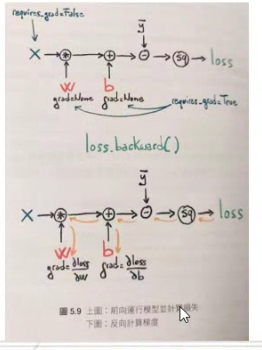

呼叫backward後導數會被累加到grad,因此需要進行自動歸零

In [246]:
parms = torch.tensor([1.0,0.0],requires_grad=True)
print(parms.grad)


None


In [247]:
def training_loop2(n_epochs, learning_rate, params, t_u, t_c, print_params=True):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:
            params.grad.zero_()
        
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()
        with torch.no_grad():
            params -= learning_rate * params.grad
        
        if epoch % 500 == 0 and print_params:
            print("Epoch:", epoch, "Loss:", loss.item())
            print("Params:", params)
            print("Grad:", params.grad)
    return params

In [248]:
training_loop2(n_epochs=5000, learning_rate=1e-2, \
                params= parms, t_u=t_un, t_c=t_c)

Epoch: 500 Loss: 6.801806449890137
Params: tensor([ 3.9999, -9.2995], requires_grad=True)
Grad: tensor([-0.1974,  1.1152])
Epoch: 1000 Loss: 4.012922286987305
Params: tensor([  4.6251, -12.8311], requires_grad=True)
Grad: tensor([-0.0731,  0.4132])
Epoch: 1500 Loss: 3.630072593688965
Params: tensor([  4.8567, -14.1396], requires_grad=True)
Grad: tensor([-0.0271,  0.1531])
Epoch: 2000 Loss: 3.5775146484375
Params: tensor([  4.9425, -14.6244], requires_grad=True)
Grad: tensor([-0.0100,  0.0567])
Epoch: 2500 Loss: 3.570300817489624
Params: tensor([  4.9743, -14.8041], requires_grad=True)
Grad: tensor([-0.0037,  0.0210])
Epoch: 3000 Loss: 3.5693106651306152
Params: tensor([  4.9861, -14.8706], requires_grad=True)
Grad: tensor([-0.0014,  0.0078])
Epoch: 3500 Loss: 3.5691750049591064
Params: tensor([  4.9904, -14.8953], requires_grad=True)
Grad: tensor([-0.0005,  0.0029])
Epoch: 4000 Loss: 3.5691545009613037
Params: tensor([  4.9920, -14.9044], requires_grad=True)
Grad: tensor([-0.0002,  0.0

tensor([  4.9929, -14.9091], requires_grad=True)

以上結果與之前相同，代表我們沒有必要手動來計算梯度Pytorch可以幫助我們得到同樣的結果

## 5.5.2 選擇優化器
PyTorch現行支援的優化器

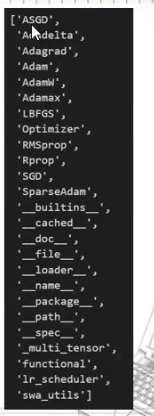

架構想法:

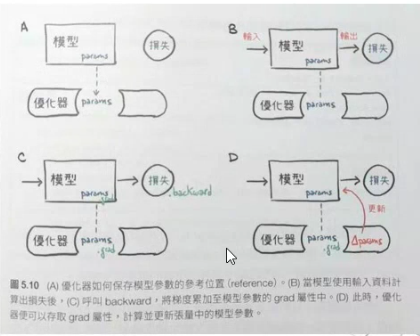

總之,利用optim模組,我們可以不用手動撰寫優化演算法的細節


In [249]:
def training_loop3(n_epochs, optimizer, params, t_u, t_c, print_params=True):
    for epoch in range(1, n_epochs + 1):
        
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if epoch % 500 == 0 and print_params:
            print("Epoch:", epoch, "Loss:", loss.item())
            print("Params:", params)
            print("Grad:", params.grad)
    return params

In [250]:
params = torch.tensor([1.0,0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = torch.optim.SGD([params], lr=learning_rate)
training_loop3(n_epochs=5000, optimizer=optimizer, \
                params= params, t_u=t_u, t_c=t_c)

Epoch: 500 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 1000 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 1500 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 2000 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 2500 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 3000 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 3500 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 4000 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 4500 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])
Epoch: 5000 Loss: nan
Params: tensor([nan, nan], requires_grad=True)
Grad: tensor([nan, nan])


tensor([nan, nan], requires_grad=True)

In [251]:
params = torch.tensor([1.0,0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = torch.optim.Adam([params], lr=learning_rate)
training_loop3(n_epochs=2000, optimizer=optimizer, \
                params= params, t_u=t_u, t_c=t_c)

Epoch: 500 Loss: 6.453185558319092
Params: tensor([ 0.4058, -9.6163], requires_grad=True)
Grad: tensor([-1.0019,  1.0686])
Epoch: 1000 Loss: 3.617339849472046
Params: tensor([  0.4872, -14.2269], requires_grad=True)
Grad: tensor([-0.1288,  0.1381])
Epoch: 1500 Loss: 3.569244384765625
Params: tensor([  0.4988, -14.8798], requires_grad=True)
Grad: tensor([-0.0058,  0.0061])
Epoch: 2000 Loss: 3.5691542625427246
Params: tensor([  0.4993, -14.9094], requires_grad=True)
Grad: tensor([-9.0607e-05,  7.2314e-05])


tensor([  0.4993, -14.9094], requires_grad=True)

## 5.5.2 選擇優化器
藉由以上的城市區塊我們已經掌握具體優化器的運算方式

## 5.5.3 訓練,驗證與過度配適
想要解決這個問題為何產生,就需要先依照克普勒在1600年所採行的方法
,透過分割訓練集和驗證集進行模型的效果驗證

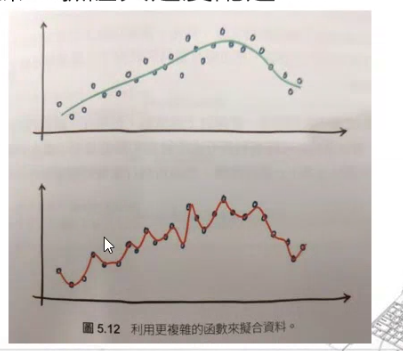

確定擁有足夠數據後,同樣也可以使用**常規化**使模型更加平穩順滑
### 切割資料集
透過隨機排列索引值的方式對輸入進行**洗牌**,洗牌後會產生兩個索引值張量,這樣就可以分割**訓練集**及**驗證集**進行模型的訓練及驗證成效

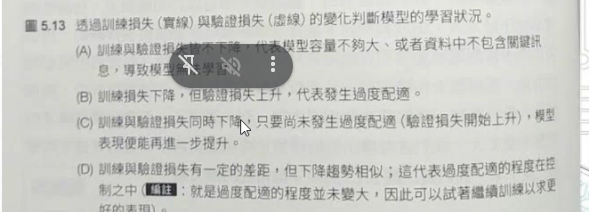

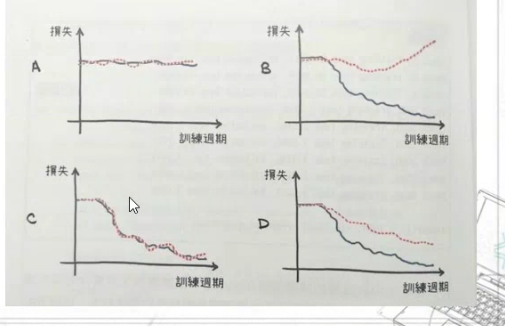

## 5.5.4 開/關Autograd的相關技巧
假設有些模型需要手動計算梯度,Pytorch提供了torch.no_grad()來進行手動計算
這些可以讓研究者針對特定細節進行修改工作